#### EDA - Análise Exploratória de Dados (EDA) 

1. Setup e carga do arquivo

In [9]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from utils.data_prep import create_label

# Estilo de visualização padrão
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)

# Carrega o dataset bruto (.csv) contendo dados de telemetria dos dispositivos
df = pd.read_csv("../data/Moto_HW_DATA_hashed.csv")

cols = df.columns.to_list()
# Seleciona apenas as colunas mais relevantes para o nosso problema
cols = [
    "full_cap_min", "btlow_total", "dchrg_diff", "total_chrg_cnt",
    "son_hrs", "msgs_tot", "wifi_hrs", "mobile_rx_MB", "age_days", "shtdn_total", "CRASH_total", "primary_mem_free_MB"
]
df = df[cols]

2. Criação de rótulo de ineficiência

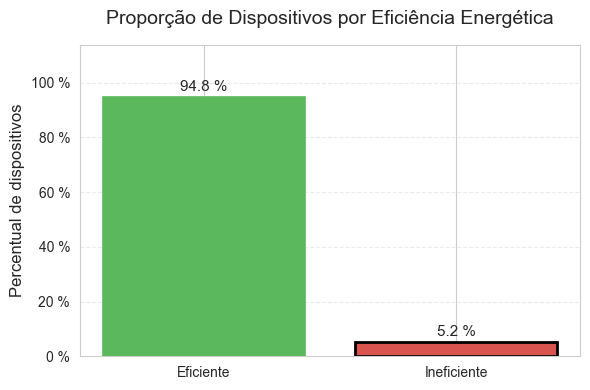

In [10]:


df = create_label(df)

# ── 4.  Checa proporção & plota ─────────────────────────────────
# 1) calcula o percentual de cada classe
counts = df["label_ineficiente"].value_counts().sort_index()
percentages = counts / counts.sum() * 100
# renomeia para algo mais legível
labels = ["Eficiente", "Ineficiente"]

# 2) cria o bar plot
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, percentages, edgecolor="black", linewidth=1.2)

# 3) anota cada barra com o seu percentual
for bar, pct in zip(bars, percentages):
    x = bar.get_x() + bar.get_width() / 2
    y = bar.get_height()
    ax.text(x, y + 1, f"{pct:.1f} %", ha="center", va="bottom", fontsize=11)

# 4) destaca visualmente a barra de "Ineficiente"
bars[1].set_color("#d9534f")       # vermelho suave
bars[0].set_color("#5cb85c")       # verde suave
bars[1].set_edgecolor("black")
bars[1].set_linewidth(2)

# 5) refinamentos finais
ax.set_ylim(0, percentages.max() * 1.2)
ax.set_ylabel("Percentual de dispositivos", fontsize=12)
ax.set_title("Proporção de Dispositivos por Eficiência Energética", fontsize=14, pad=15)
ax.yaxis.set_major_formatter(lambda x, pos: f"{int(x)} %")
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

3. Visão geral

In [11]:
# Informações gerais do DataFrame (tipos, nulls, memória)
df.info()

# Estatísticas descritivas básicas para cada coluna
df.describe().T   


# Conta valores ausentes por coluna (se houver)
na = df.isna().sum().sort_values(ascending=False)
display(na[na > 0])   # Exibe apenas colunas com NaN

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21063 entries, 0 to 21062
Data columns (total 56 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   barcode_hashed             21063 non-null  object 
 1   age_days                   21063 non-null  int64  
 2   full_cap_min               21063 non-null  float64
 3   pct_lvl_max                21063 non-null  float64
 4   min_dchrg_fcc              21063 non-null  float64
 5   dchrg_diff                 21063 non-null  float64
 6   EBL                        21063 non-null  float64
 7   total_chrg_cnt             21063 non-null  float64
 8   cnt_USB_chrg               21063 non-null  float64
 9   shtdn_total                21063 non-null  float64
 10  btlow_total                21063 non-null  float64
 11  call_drop_sum              21063 non-null  float64
 12  call_tot_mins              21063 non-null  float64
 13  calls_tot                  11098 non-null  flo

calls_tot              9965
msgs_tot               9677
pics_tot               9592
primary_mem_free_MB       9
dtype: int64

/var/folders/nk/hhm4r_k11vj25bs27s2w2ch40000gn/T/ipykernel_25413/1682643801.py:48: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df, x=c, hue="label_ineficiente", common_norm=False)
/var/folders/nk/hhm4r_k11vj25bs27s2w2ch40000gn/T/ipykernel_25413/1682643801.py:48: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df, x=c, hue="label_ineficiente", common_norm=False)


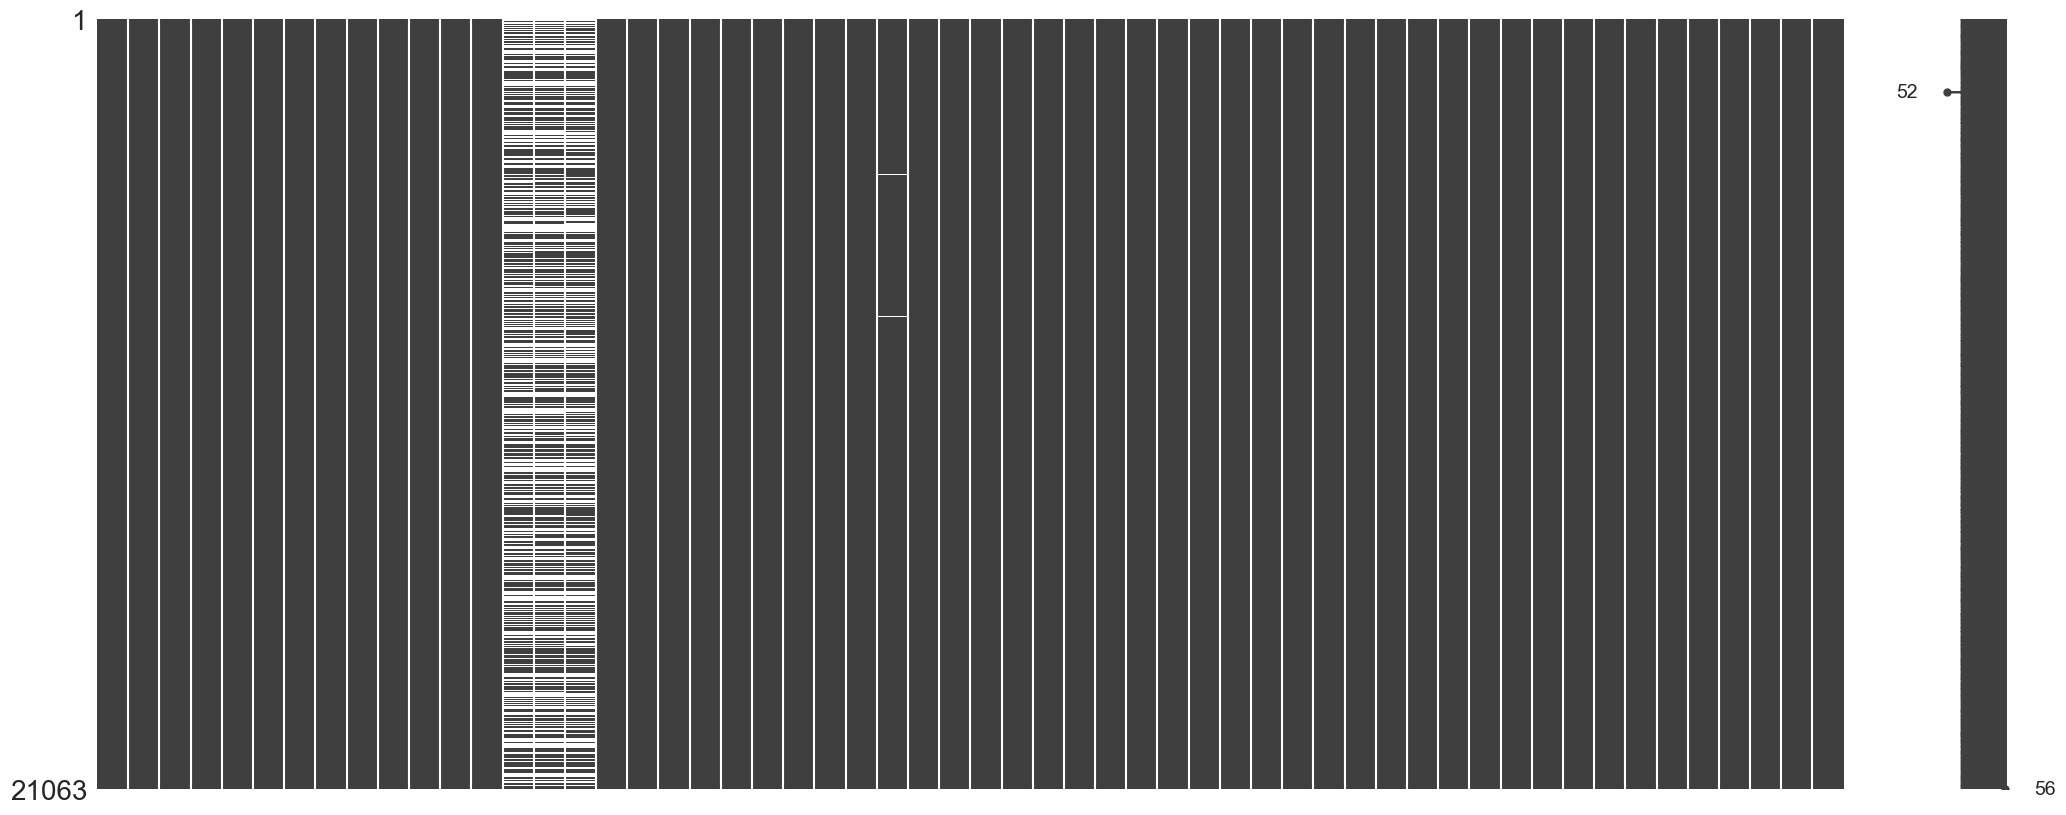

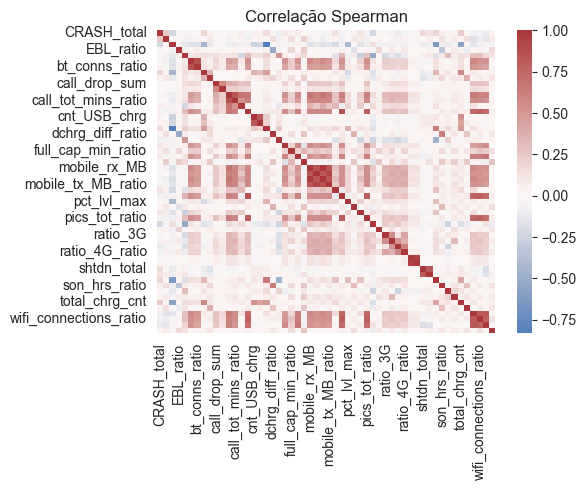

In [14]:
# Importa bibliotecas para visualização de missing values e análise de forma da distribuição
import missingno as msno
from scipy.stats import skew, kurtosis

# --- Visualização gráfica de valores ausentes (linhas brancas = valores faltantes)
# Apenas a coluna msgs_tot mostra ausências, o que é excelente.
msno.matrix(df)
plt.savefig("../outputs/figures/eda_missing_matrix.png")

# --- Tabela de medidas estatísticas adicionais: skew (assimetria) e kurtosis (cauda)

# Para cada coluna, calcula estatísticas que ajudam a decidir se devemos aplicar transformação logarítmica
# 1) Identifica colunas numéricas puras
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# 2) (Opcional) Se quiser incluir colunas object conversíveis:
for col in df.select_dtypes(include=["object"]):
    coerced = pd.to_numeric(df[col], errors="coerce")
    # se 80%+ virar número, consideramos conversível
    if coerced.count() / len(df) > 0.8:
        df[col] = coerced
        numeric_cols.append(col)

# 3) Remove duplicatas e quaisquer colunas que não queira
numeric_cols = sorted(set(numeric_cols) - {"label_ineficiente"})

# 4) Agora gera o heatmap só com elas
plt.figure(figsize=(6,5))
sns.heatmap(
    df[numeric_cols]
      .corr(method="spearman"),
    cmap="vlag",
    center=0,
    annot=False
)
plt.title("Correlação Spearman")
plt.tight_layout()
plt.savefig("../outputs/figures/eda_corr.png")

# Comentário analítico:
# - Correlações baixas entre variáveis principais → bom sinal, pois evita multicolinearidade excessiva

# --- Distribuições de cada variável separadas por rótulo (ineficiente ou não)

# --- KDE apenas nas numéricas
for c in numeric_cols:
    plt.figure()
    sns.kdeplot(data=df, x=c, hue="label_ineficiente", common_norm=False)
    plt.title(f"{c} vs label")
    plt.savefig(f"../outputs/figures/eda_{c}_kde.png")
    plt.close()
    
# Comentário analítico:
# - Permite observar se alguma variável "separa" bem os rótulos
# - Exemplo: full_cap_min tende a ser menor para aparelhos ineficientes

### 📌 Insights Extraídos
- Apenas `msgs_tot` possui valores ausentes (recomendado fillna).
- 6 variáveis apresentam alta assimetria (skew > 3) e devem ser transformadas com log1p.
- As variáveis `full_cap_min`, `btlow_total` e `wifi_hrs` mostram bom poder discriminativo para o rótulo.
- Correlações baixas entre variáveis: bom sinal para modelagem.